# Formula SAE optimal lap — standard Pacejka

This notebook runs the reduced standard Pacejka FSAE vehicle on the 1.25 km Vendrell circuit. The tire fit is embedded in the vehicle XML, so the original MATLAB tire file is not required at run time.

The standard and simple notebooks deliberately use the same track, mesh, solver options, channels, and plots. This makes their results directly comparable. Tire sign, slip, pressure, load, and inclination conventions were already normalized when the reduced XML was generated.

## 1. Locate the repository and Python runtime

The recommended kernel is the Conda fastest-lap environment. If it is not listed in Jupyter, register it once with python -m ipykernel install --user --name fastest-lap --display-name "Python (fastest-lap)". Set FASTESTLAP_PYTHON_DIR only when the Fastest-lap Python wrapper is outside this repository.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None


def find_repository_root(start=Path.cwd()):
    start = start.resolve()
    for directory in (start, *start.parents):
        if (directory / "database" / "vehicles" / "fsae").is_dir():
            return directory
    raise FileNotFoundError("Start Jupyter from inside the fastest-lap repository.")


REPO_ROOT = find_repository_root()
runtime_candidates = []
configured_runtime = os.environ.get("FASTESTLAP_PYTHON_DIR")
if configured_runtime:
    runtime_candidates.append(Path(configured_runtime).expanduser())

runtime_candidates.extend(
    (
        REPO_ROOT / "build" / "windows-mingw64" / "python",
        REPO_ROOT / "build" / "python",
    )
)
artifacts = REPO_ROOT / "build" / "artifacts"
if artifacts.is_dir():
    runtime_candidates.extend(sorted(artifacts.glob("fastestlap-python-*/python")))

runtime_path = None
DLL_DIRECTORY_HANDLES = []
for candidate in runtime_candidates:
    if not candidate.is_dir():
        continue
    runtime_path = candidate.resolve()
    sys.path.insert(0, str(runtime_path))
    if os.name == "nt" and hasattr(os, "add_dll_directory"):
        for directory in (
            runtime_path,
            runtime_path.parent / "bin",
            runtime_path.parent / "src" / "test" / "tire",
        ):
            if directory.is_dir():
                DLL_DIRECTORY_HANDLES.append(os.add_dll_directory(str(directory)))
    break

try:
    import fastest_lap
except (ImportError, OSError) as exc:
    raise RuntimeError(
        "Could not load fastest_lap. Build/install the Python runtime or set "
        "FASTESTLAP_PYTHON_DIR to its python directory."
    ) from exc

required_api = (
    "create_vehicle_from_xml",
    "create_track_from_xml",
    "optimal_laptime",
    "download_variables",
)
missing_api = [name for name in required_api if not hasattr(fastest_lap, name)]
if missing_api:
    raise RuntimeError(f"fastest_lap runtime is missing: {', '.join(missing_api)}")

print(f"repository: {REPO_ROOT}")
print(f"runtime:    {runtime_path or Path(fastest_lap.__file__).resolve().parent}")

repository: D:\projects\fastest-lap
runtime:    D:\projects\fastest-lap\build\windows-mingw64\python


## 2. Load the reduced standard Pacejka vehicle

The expected registry type is checked explicitly. Unlike the original FRUCD MF vehicle, this XML has no mat-file field and needs no external tire-data path.

In [2]:
VEHICLE = "fsae-pacejka-optimal-lap-notebook"
VEHICLE_XML = (
    REPO_ROOT / "database" / "vehicles" / "fsae" / "fsae-2026-pacejka.xml"
)
EXPECTED_VEHICLE_TYPE = "fsae-pacejka-3dof"
OUTPUT_PREFIX = "fsae_pacejka_notebook/"

if not VEHICLE_XML.is_file():
    raise FileNotFoundError(VEHICLE_XML)

# These names are notebook-specific, so clearing them makes this cell rerunnable.
fastest_lap.delete_variable(OUTPUT_PREFIX + "*")
fastest_lap.delete_variable(VEHICLE)
fastest_lap.create_vehicle_from_xml(VEHICLE, str(VEHICLE_XML))

actual_vehicle_type = fastest_lap.variable_type(VEHICLE)
if actual_vehicle_type != EXPECTED_VEHICLE_TYPE:
    fastest_lap.delete_variable(VEHICLE)
    raise RuntimeError(
        f"Expected {EXPECTED_VEHICLE_TYPE}, loaded {actual_vehicle_type}"
    )

print(f"vehicle XML:  {VEHICLE_XML}")
print(f"vehicle type: {actual_vehicle_type}")

vehicle XML:  D:\projects\fastest-lap\database\vehicles\fsae\fsae-2026-pacejka.xml
vehicle type: fsae-pacejka-3dof


## 3. Load Vendrell and choose the optimization mesh

The default uses every second track point, approximately 250 optimization nodes. Set mesh_stride to 1 for the full mesh or increase it for a quicker exploratory solve.

In [3]:
TRACK = "vendrell-fsae-pacejka-notebook"
TRACK_XML = REPO_ROOT / "database" / "tracks" / "vendrell" / "vendrell.xml"

if not TRACK_XML.is_file():
    raise FileNotFoundError(TRACK_XML)

fastest_lap.delete_variable(TRACK)
fastest_lap.create_track_from_xml(TRACK, str(TRACK_XML))

s_track = np.asarray(fastest_lap.track_download_data(TRACK, "arclength"))
mesh_stride = 2
s_mesh = s_track[::mesh_stride]
if s_mesh.size < 10:
    raise ValueError("The optimization mesh needs at least 10 points.")

print(f"track length:       {s_track[-1]:.1f} m")
print(f"optimization nodes: {s_mesh.size}")

track length:       1250.7 m
optimization nodes: 250


## 4. Solve the minimum-lap-time problem

Positive chassis.throttle means drive torque and negative values mean braking. The print level is zero to keep notebook output concise; change it to 5 when detailed Ipopt progress is useful.

In [4]:
options = f"""
<options>
  <output_variables>
    <prefix>{OUTPUT_PREFIX}</prefix>
  </output_variables>
  <print_level>0</print_level>
</options>
"""

result_names = fastest_lap.optimal_laptime(VEHICLE, TRACK, s_mesh, options)
run = fastest_lap.download_variables(*result_names)

required_channels = (
    "road.arclength",
    "time",
    "chassis.position.x",
    "chassis.position.y",
    "chassis.velocity.x",
    "front-axle.steering-angle",
    "chassis.throttle",
)
missing_channels = [name for name in required_channels if name not in run]
if missing_channels:
    raise RuntimeError(f"Missing optimal-lap channels: {missing_channels}")

s = np.asarray(run["road.arclength"])
time = np.asarray(run["time"])
x = np.asarray(run["chassis.position.x"])
y = np.asarray(run["chassis.position.y"])
speed_kmh = 3.6 * np.asarray(run["chassis.velocity.x"])
steering_deg = np.rad2deg(np.asarray(run["front-axle.steering-angle"]))
throttle = np.asarray(run["chassis.throttle"])

for name, values in (
    ("time", time),
    ("x", x),
    ("y", y),
    ("speed", speed_kmh),
    ("steering", steering_deg),
    ("throttle", throttle),
):
    if not np.all(np.isfinite(values)):
        raise RuntimeError(f"Channel {name} contains non-finite values.")

lap_time = float(time[-1])
print(f"optimal lap time: {lap_time:.3f} s")
print(f"speed range: {speed_kmh.min():.1f} to {speed_kmh.max():.1f} km/h")

optimal lap time: 56.157 s
speed range: 50.0 to 130.2 km/h


## 5. Inspect the racing line

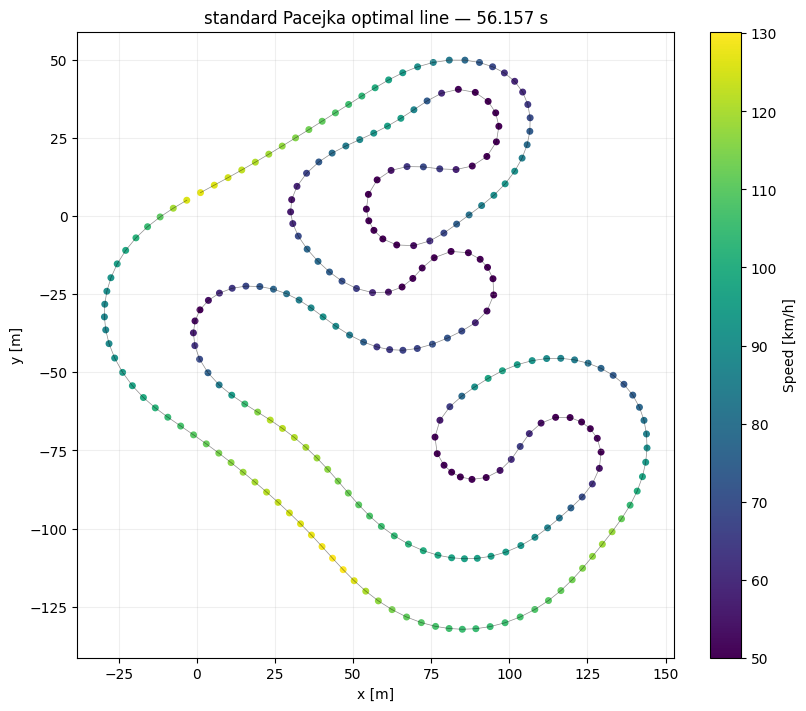

In [5]:
if plt is None:
    print("Install Matplotlib to display the racing-line plot.")
else:
    figure, axis = plt.subplots(figsize=(8, 7), constrained_layout=True)
    points = axis.scatter(x, y, c=speed_kmh, s=16, cmap="viridis")
    axis.plot(x, y, color="black", linewidth=0.5, alpha=0.45)
    axis.set(
        xlabel="x [m]",
        ylabel="y [m]",
        title=f"standard Pacejka optimal line — {lap_time:.3f} s",
    )
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.2)
    figure.colorbar(points, ax=axis, label="Speed [km/h]")
    plt.show()

## 6. Inspect speed and driver controls

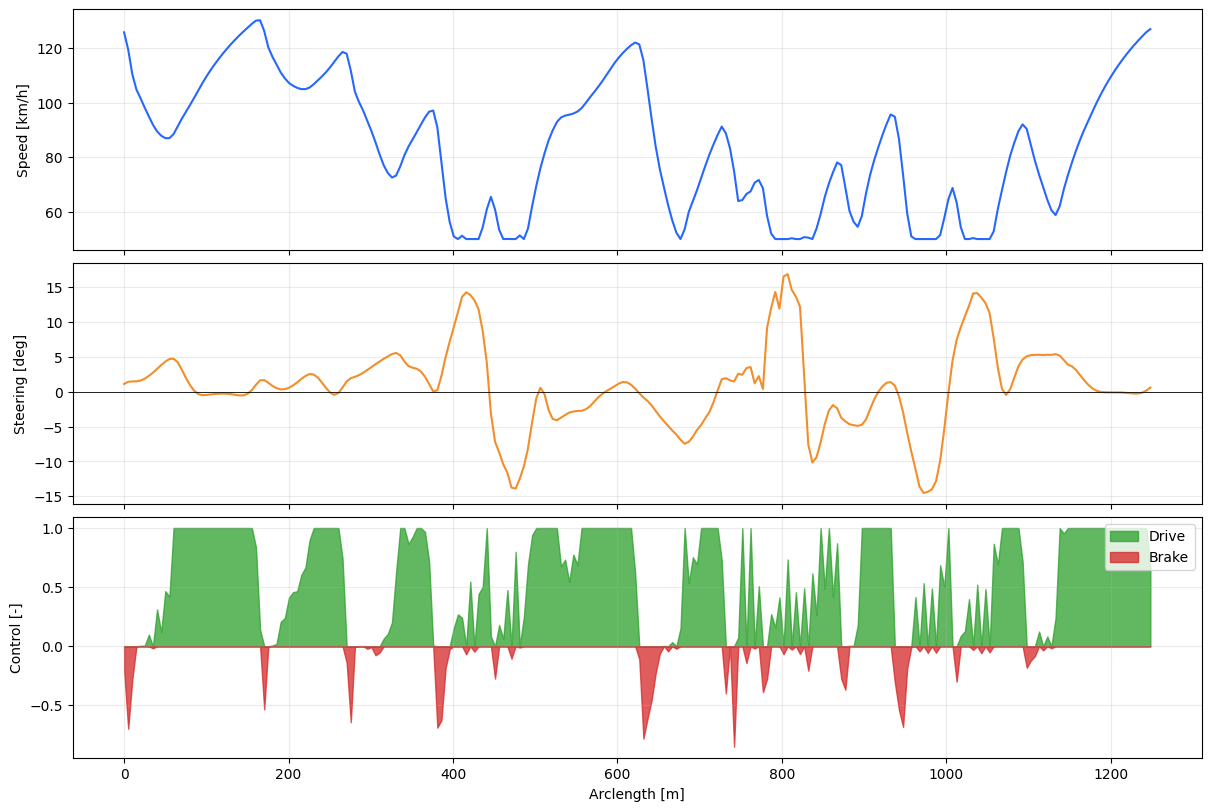

In [6]:
if plt is None:
    print("Install Matplotlib to display the control plots.")
else:
    figure, axes = plt.subplots(
        3, 1, figsize=(12, 8), sharex=True, constrained_layout=True
    )
    axes[0].plot(s, speed_kmh, color="#2667ff")
    axes[0].set_ylabel("Speed [km/h]")

    axes[1].plot(s, steering_deg, color="#f28e2b")
    axes[1].axhline(0.0, color="black", linewidth=0.6)
    axes[1].set_ylabel("Steering [deg]")

    axes[2].fill_between(
        s, 0.0, np.maximum(throttle, 0.0),
        label="Drive", color="#2ca02c", alpha=0.75,
    )
    axes[2].fill_between(
        s, 0.0, np.minimum(throttle, 0.0),
        label="Brake", color="#d62728", alpha=0.75,
    )
    axes[2].set(xlabel="Arclength [m]", ylabel="Control [-]")
    axes[2].legend(loc="upper right")

    for axis in axes:
        axis.grid(True, alpha=0.25)
    plt.show()

## 7. Clean up

Run this cell after inspecting the results. It removes this notebook's output, vehicle, and track objects from the Fastest-lap registry.

In [7]:
fastest_lap.delete_variable(OUTPUT_PREFIX + "*")
fastest_lap.delete_variable(VEHICLE)
fastest_lap.delete_variable(TRACK)
print("Standard Pacejka notebook objects removed.")

Standard Pacejka notebook objects removed.
